In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:

import sys
import os

PROJECT_ROOT = "/content/drive/MyDrive/mining_ofMassive"
STDN_DIR = os.path.join(PROJECT_ROOT, "STDN")
DATA_ROOT = os.path.join(PROJECT_ROOT, "Data_V_F", "prepare_6-12_2024")

if STDN_DIR not in sys.path:
    sys.path.append(STDN_DIR)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("STDN_DIR:", STDN_DIR)
print("DATA_ROOT:", DATA_ROOT)


PROJECT_ROOT: /content/drive/MyDrive/mining_ofMassive
STDN_DIR: /content/drive/MyDrive/mining_ofMassive/STDN
DATA_ROOT: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024


In [14]:
import os

print("Dataset files:", os.listdir(DATA_ROOT))
print("STDN files:", os.listdir(STDN_DIR))

Dataset files: ['volume_test.npz', 'volume_train.npz', 'flow_train.npz', 'flow_test.npz', 'context_train.npz', 'context_test.npz', 'data.json']
STDN files: ['file_loader.py', 'main.py', 'data.json', 'attention.py', 'file_loader_lazy.py', 'models.py', '.git', '__pycache__']


## Hyperparamter for model

In [15]:
import sys
print(sys.executable)

/usr/bin/python3


In [16]:
class Args:
    dataset = 'taxi'
    batch_size = 64
    max_epochs = 2
    att_lstm_num = 3
    long_term_lstm_seq_len = 3
    short_term_lstm_seq_len = 7
    cnn_nbhd_size = 3
    nbhd_size = 2
    cnn_flat_size = 128
    learning_rate = 1e-4

args = Args()

In [17]:

import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

from models import models as models_module
from file_loader_lazy import STDNLazyDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [18]:

import json
import os

# Dataset m?i ?? ???c build t? th?ng 06-12/2024 v? c? context aligned theo time.
source_config_path = os.path.join(DATA_ROOT, "data.json")
with open(source_config_path, "r") as f:
    config = json.load(f)

# data.json ???c build local c? th? ch?a Windows path; tr?n Colab ta override v? Drive path.
config.update({
    "volume_train": os.path.join(DATA_ROOT, "volume_train.npz"),
    "volume_test": os.path.join(DATA_ROOT, "volume_test.npz"),
    "flow_train": os.path.join(DATA_ROOT, "flow_train.npz"),
    "flow_test": os.path.join(DATA_ROOT, "flow_test.npz"),
    "context_train": os.path.join(DATA_ROOT, "context_train.npz"),
    "context_test": os.path.join(DATA_ROOT, "context_test.npz"),
})

with open("data.json", "w") as f:
    json.dump(config, f, indent=2)

print("Created runtime data.json")
print("Train volume:", config["volume_train"])
print("Train context:", config["context_train"])
print("Context dim:", config.get("context_dim"))
print("Metric volume max:", config.get("raw_volume_train_max", config.get("volume_train_max")))


Created runtime data.json
Train volume: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024/volume_train.npz
Train context: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024/context_train.npz
Context dim: 8
Metric volume max: 1966.0


In [19]:

import numpy as np
import torch

class ContextSTDNLazyDataset(STDNLazyDataset):
    """STDNLazyDataset plus aligned additive context features."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        context_key = f"context_{self.datatype}"
        if context_key not in self.config:
            raise KeyError(f"Missing {context_key} in data.json")

        context_npz = np.load(self.config[context_key], allow_pickle=True)
        self.context = np.asarray(context_npz["context"], dtype=np.float32)
        self.context_time = np.asarray(context_npz["time"]).astype(str)
        self.context_feature_names = np.asarray(context_npz["feature_names"]).astype(str).tolist()
        self.context_dim = int(self.context.shape[1])

        volume_key = f"volume_{self.datatype}"
        flow_key = f"flow_{self.datatype}"
        volume_npz = np.load(self.config[volume_key], allow_pickle=True)
        flow_npz = np.load(self.config[flow_key], allow_pickle=True)

        self.volume_time = np.asarray(volume_npz["time"]).astype(str) if "time" in volume_npz.files else None
        self.flow_time = np.asarray(flow_npz["time"]).astype(str) if "time" in flow_npz.files else None

        if len(self.context) != self.time_count:
            raise ValueError(f"Context length {len(self.context)} != volume length {self.time_count}")
        if self.volume_time is not None and not np.array_equal(self.volume_time, self.context_time):
            raise ValueError("volume time and context time are not aligned")
        if self.flow_time is not None and not np.array_equal(self.flow_time, self.context_time):
            raise ValueError("flow time and context time are not aligned")

    def sample_shape_info(self):
        info = super().sample_shape_info()
        info["context_dim"] = self.context_dim
        info["context_feature_names"] = self.context_feature_names
        return info

    def _context_feature(self, real_t):
        return np.asarray(self.context[real_t], dtype=np.float32)

    def __getitem__(self, idx):
        base = super().__getitem__(idx)
        t, x, y = self._decode_index(idx)

        context_samples = []
        for seqn in range(self.short_term_lstm_seq_len):
            real_t = t - (self.short_term_lstm_seq_len - seqn)
            context_samples.append(self._context_feature(real_t))
        context_features = torch.from_numpy(np.asarray(context_samples, dtype=np.float32)).float()

        att_context_features = []
        for att_lstm_cnt in range(self.att_lstm_num):
            long_context_samples = []
            att_t = t - (self.att_lstm_num - att_lstm_cnt) * self.timeslot_daynum
            att_t += int((self.long_term_lstm_seq_len - 1) / 2 + 1)

            for seqn in range(self.long_term_lstm_seq_len):
                real_t = att_t - (self.long_term_lstm_seq_len - seqn)
                long_context_samples.append(self._context_feature(real_t))

            att_context_features.append(torch.from_numpy(np.asarray(long_context_samples, dtype=np.float32)).float())

        att_context_features = torch.stack(att_context_features, dim=0)
        return (*base, context_features, att_context_features)


def context_collate_fn(batch):
    att_cnn, att_flow, att_lstm, cnn, flow, lstm, label, context, att_context = zip(*batch)

    att_cnn_stacked = [torch.stack([sample[i] for sample in att_cnn]) for i in range(len(att_cnn[0]))]
    att_cnn_stacked = [x.permute(0, 3, 1, 2) for x in att_cnn_stacked]

    att_flow_stacked = [torch.stack([sample[i] for sample in att_flow]) for i in range(len(att_flow[0]))]
    att_flow_stacked = [x.permute(0, 3, 1, 2) for x in att_flow_stacked]

    att_lstm_stacked = [torch.stack([sample[i] for sample in att_lstm]) for i in range(len(att_lstm[0]))]

    cnn_stacked = [torch.stack([sample[i] for sample in cnn]) for i in range(len(cnn[0]))]
    cnn_stacked = [x.permute(0, 3, 1, 2) for x in cnn_stacked]

    flow_stacked = [torch.stack([sample[i] for sample in flow]) for i in range(len(flow[0]))]
    flow_stacked = [x.permute(0, 3, 1, 2) for x in flow_stacked]

    lstm_stacked = torch.stack(lstm)
    label_stacked = torch.stack(label)
    context_stacked = torch.stack(context)
    att_context_stacked = torch.stack(att_context)

    return (
        att_cnn_stacked,
        att_flow_stacked,
        att_lstm_stacked,
        cnn_stacked,
        flow_stacked,
        lstm_stacked,
        label_stacked,
        context_stacked,
        att_context_stacked,
    )


dataset = ContextSTDNLazyDataset(
    datatype="train",
    config_path="data.json",
    att_lstm_num=args.att_lstm_num,
    long_term_lstm_seq_len=args.long_term_lstm_seq_len,
    short_term_lstm_seq_len=args.short_term_lstm_seq_len,
    nbhd_size=args.nbhd_size,
    cnn_nbhd_size=args.cnn_nbhd_size,
)

info = dataset.sample_shape_info()
print(info)
print("Dataset time range:", dataset.context_time[0], "->", dataset.context_time[-1])


{'n_samples': 1546800, 'time_start': 483, 'time_end': 8217, 'grid_h': 10, 'grid_w': 20, 'volume_type': 2, 'feature_vec_len': 160, 'cnn_nbhd_dim': 7, 'context_dim': 8, 'context_feature_names': ['Legal_Holiday_effect', 'School_Recess_effect', 'Event_Festival_effect', 'Early_Dismissal_effect', 'temperature_effect', 'cloudcover_effect', 'windspeed_effect', 'rain_intensity_effect']}
Dataset time range: 2024-06-01 00:00:00 -> 2024-11-19 04:00:00


## Dataset class

In [20]:
class STDNDataset(torch.utils.data.Dataset):
    """Custom dataset for STDN"""
    def __init__(self, att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels):
        self.att_cnn = att_cnn
        self.att_flow = att_flow
        self.att_lstm = att_lstm
        self.cnn = cnn
        self.flow = flow
        self.lstm = lstm
        self.labels = labels

        # Number of samples
        self.n_samples = lstm.shape[0]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Collect features for this sample across all time steps
        att_cnn_sample = [self.att_cnn[i][idx] for i in range(len(self.att_cnn))]
        att_flow_sample = [self.att_flow[i][idx] for i in range(len(self.att_flow))]
        att_lstm_sample = [self.att_lstm[i][idx] for i in range(len(self.att_lstm))]
        cnn_sample = [self.cnn[i][idx] for i in range(len(self.cnn))]
        flow_sample = [self.flow[i][idx] for i in range(len(self.flow))]
        lstm_sample = self.lstm[idx]
        label_sample = self.labels[idx]

        return att_cnn_sample, att_flow_sample, att_lstm_sample, cnn_sample, flow_sample, lstm_sample, label_sample

In [21]:

# Split theo th?i gian, kh?ng random, ?? tr?nh leakage gi?a c?c slot g?n nhau.
n_time = dataset.target_time_count
n_val_time = int(n_time * 0.2)
n_train_time = n_time - n_val_time
cell_count = dataset.cell_count

train_indices = range(0, n_train_time * cell_count)
val_indices = range(n_train_time * cell_count, n_time * cell_count)

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)
n_train = len(train_dataset)
n_val = len(val_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    shuffle=True,
    collate_fn=context_collate_fn,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    collate_fn=context_collate_fn,
    num_workers=0,
)

print("Train size:", n_train)
print("Val size:", n_val)
print("Train target time slots:", n_train_time)
print("Val target time slots:", n_val_time)


Train size: 1237600
Val size: 309200
Train target time slots: 6188
Val target time slots: 1546


In [22]:
# Dữ liệu đã được scale sẵn về [0, 1] trong quá trình tạo file NPZ
print("Dữ liệu đã sẵn sàng ở dạng chuẩn hóa [0, 1].")
print("Bỏ qua các bước transform bổ sung.")

Dữ liệu đã sẵn sàng ở dạng chuẩn hóa [0, 1].
Bỏ qua các bước transform bổ sung.


In [23]:

modeler = models_module()

model1 = modeler.stdn(
    att_lstm_num=args.att_lstm_num,
    att_lstm_seq_len=args.long_term_lstm_seq_len,
    lstm_seq_len=args.short_term_lstm_seq_len,
    feature_vec_len=info["feature_vec_len"],
    cnn_flat_size=args.cnn_flat_size,
    nbhd_size=info["cnn_nbhd_dim"],
    nbhd_type=info["volume_type"],
    context_dim=info["context_dim"],
)

model1.to(device)
print("Model ready with context_dim:", info["context_dim"])


Model ready with context_dim: 8


In [24]:
model1

STDN(
  (dropout): Dropout(p=0.5, inplace=False)
  (context_projection): Linear(in_features=8, out_features=64, bias=True)
  (nbhd_convs_level0): ModuleList(
    (0-6): 7 x Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (flow_convs_level0): ModuleList(
    (0-6): 7 x Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (nbhd_convs_level1): ModuleList(
    (0-6): 7 x Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (flow_convs_level1): ModuleList(
    (0-6): 7 x Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (nbhd_convs_level2): ModuleList(
    (0-6): 7 x Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (flow_convs_level2): ModuleList(
    (0-6): 7 x Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (nbhd_dense): ModuleList(
    (0-6): 7 x Linear(in_features=3136, out_features=128, bias=True)
  )
  (short_term_lstm): LSTM(288, 128, batch_first=True)
  (att

In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model1.parameters(), lr=args.learning_rate)

## Training phase

In [26]:

from tqdm.auto import tqdm
import numpy as np
import torch
from sklearn.metrics import r2_score


def _move_context_batch_to_device(batch, device):
    att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels, context, att_context = batch
    att_cnn = [x.to(device) for x in att_cnn]
    att_flow = [x.to(device) for x in att_flow]
    att_lstm = [x.to(device) for x in att_lstm]
    cnn = [x.to(device) for x in cnn]
    flow = [x.to(device) for x in flow]
    lstm = lstm.to(device)
    labels = labels.to(device)
    context = context.to(device)
    att_context = att_context.to(device)
    return att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels, context, att_context


def train_epoch_scaled(model, train_loader, optimizer, criterion, device):
    """Hu?n luy?n tr?c ti?p tr?n d? li?u [0, 1] + additive context."""
    model.train()
    total_loss = 0
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Training", leave=False)

    for batch_idx, batch in pbar:
        att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels, context, att_context = _move_context_batch_to_device(batch, device)

        optimizer.zero_grad()
        outputs = model(
            att_cnn,
            att_flow,
            att_lstm,
            cnn,
            flow,
            lstm,
            context_inputs=context,
            att_context_inputs=att_context,
        )
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        pbar.set_postfix({"loss": f"{loss.item():.6f}"})
        if (batch_idx + 1) % 25 == 0:
            pbar.write(f"Batch [{batch_idx + 1}/{len(train_loader)}] - Loss: {loss.item():.6f}")

    return total_loss / len(train_loader)


def validate_scaled(model, val_loader, criterion, device, config):
    """Ki?m th? v? denormalize v? ??n v? g?c ?? t?nh metrics."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    v_max = float(config.get("raw_volume_train_max", config.get("volume_train_max", 1.0))) + 1e-6

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels, context, att_context = _move_context_batch_to_device(batch, device)

            outputs = model(
                att_cnn,
                att_flow,
                att_lstm,
                cnn,
                flow,
                lstm,
                context_inputs=context,
                att_context_inputs=att_context,
            )
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds_orig = np.concatenate(all_preds, axis=0) * v_max
    all_labels_orig = np.concatenate(all_labels, axis=0) * v_max

    rmse = np.sqrt(np.mean(np.square(all_labels_orig - all_preds_orig)))
    wmape = np.sum(np.abs(all_labels_orig - all_preds_orig)) / (np.sum(all_labels_orig) + 1e-5) * 100
    r2 = r2_score(all_labels_orig.flatten(), all_preds_orig.flatten())

    print(f"\n[Val] Scaled MSE: {total_loss/len(val_loader):.6f} | RMSE: {rmse:.4f} trips | WMAPE: {wmape:.2f}% | R2: {r2:.4f}")

    return total_loss / len(val_loader), rmse, wmape, r2

print("Updated: Training and validation now use context inputs.")


Updated: Training and validation now use context inputs.


In [27]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model1.parameters(), lr=args.learning_rate)

In [ ]:

from tqdm.auto import tqdm

epoch_pbar = tqdm(range(args.max_epochs), desc="Epochs")

for epoch in epoch_pbar:
    train_loss = train_epoch_scaled(model1, train_loader, optimizer, criterion, device)

    val_loss, val_rmse, val_wmape, r2 = validate_scaled(
        model1, val_loader, criterion, device, config
    )

    epoch_pbar.set_description(f"Epoch {epoch+1} - Val Loss: {val_loss:.6f}")


Epochs:   0%|          | 0/2 [00:00<?, ?it/s]

Training:   0%|          | 0/19338 [00:00<?, ?it/s]

Batch [25/19338] - Loss: 0.000001
Batch [50/19338] - Loss: 0.000001
Batch [75/19338] - Loss: 0.000012
Batch [100/19338] - Loss: 0.000013
Batch [125/19338] - Loss: 0.000009
Batch [150/19338] - Loss: 0.000009
Batch [175/19338] - Loss: 0.000007
Batch [200/19338] - Loss: 0.000023
Batch [225/19338] - Loss: 0.000002
Batch [250/19338] - Loss: 0.000005
Batch [275/19338] - Loss: 0.000017
Batch [300/19338] - Loss: 0.000020
Batch [325/19338] - Loss: 0.000020
Batch [350/19338] - Loss: 0.000008
Batch [375/19338] - Loss: 0.000004
Batch [400/19338] - Loss: 0.000003
Batch [425/19338] - Loss: 0.000135
Batch [450/19338] - Loss: 0.000030
Batch [475/19338] - Loss: 0.000020
Batch [500/19338] - Loss: 0.000018
Batch [525/19338] - Loss: 0.000024
Batch [550/19338] - Loss: 0.000031
Batch [575/19338] - Loss: 0.000007
Batch [600/19338] - Loss: 0.000032
Batch [625/19338] - Loss: 0.000001
Batch [650/19338] - Loss: 0.000004
Batch [675/19338] - Loss: 0.000025
Batch [700/19338] - Loss: 0.000002
Batch [725/19338] - Los

In [ ]:

# Optional: ch?y th?m n?u b?n mu?n ti?p t?c train th?m args.max_epochs epoch n?a.
# for epoch in tqdm(range(args.max_epochs), desc="Extra epochs"):
#     train_loss = train_epoch_scaled(model1, train_loader, optimizer, criterion, device)
#     val_loss, val_rmse, val_wmape, r2 = validate_scaled(model1, val_loader, criterion, device, config)
#     print(f"Extra epoch {epoch+1}: val_loss={val_loss:.6f}, val_rmse={val_rmse:.4f}, val_wmape={val_wmape:.2f}%, r2={r2:.4f}")


In [29]:

print(f"--- Final Epoch Summary ---")
print(f"Train Loss (MSE): {train_loss:.6f}")
print(f"Val Loss (MSE):   {val_loss:.6f}")
print(f"\nVal Metrics (Real-Scale):")
print(f"  Overall RMSE: {val_rmse:.4f} (trips)")
print(f"  WMAPE:        {val_wmape:.2f}%")
print(f"  R? Score:     {r2:.4f}")


--- Final Epoch Summary ---
Train Loss (MSE): 0.000047
Val Loss (MSE):   0.000023

Val Metrics (Real-Scale):
  Overall RMSE: 9.3992 (trips)
  WMAPE:        20.20%
  R? Score:     0.9804


In [30]:

model_path = os.path.join(DATA_ROOT, "stdn_context_jun_dec_2024.pth")
torch.save(model1.state_dict(), model_path)
print("Saved model to:", model_path)


Saved model to: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024/stdn_context_jun_dec_2024.pth


## Testing on Held-Out Jun-Dec 2024 Test Split


In [31]:

# Test split ???c build s?n t? script DataPreparing/build_jun_dec_dataset.py
# v? c? volume/flow/context/time aligned v?i nhau.
test_dataset = ContextSTDNLazyDataset(
    datatype="test",
    config_path="data.json",
    att_lstm_num=args.att_lstm_num,
    long_term_lstm_seq_len=args.long_term_lstm_seq_len,
    short_term_lstm_seq_len=args.short_term_lstm_seq_len,
    nbhd_size=args.nbhd_size,
    cnn_nbhd_size=args.cnn_nbhd_size,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    collate_fn=context_collate_fn,
    num_workers=0,
)

print("Test samples:", len(test_dataset))
print("Test target time slots:", test_dataset.target_time_count)
print("Test time range:", test_dataset.context_time[0], "->", test_dataset.context_time[-1])


Test samples: 314400
Test target time slots: 1572
Test time range: 2024-11-19 04:30:00 -> 2024-12-31 23:30:00


In [32]:

# Preview m?t batch ?? ch?c ch?n context ?i c?ng batch.
batch = next(iter(test_loader))
print("Batch items:", len(batch))
print("context shape:", batch[7].shape)
print("att_context shape:", batch[8].shape)


Batch items: 9
context shape: torch.Size([64, 7, 8])
att_context shape: torch.Size([64, 3, 3, 8])


In [33]:

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import r2_score


def test_and_visualize(model, test_loader, config, device, num_plot=100):
    model.eval()
    all_preds = []
    all_labels = []
    v_max = float(config.get("raw_volume_train_max", config.get("volume_train_max", 1.0))) + 1e-6

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing Progress"):
            att_cnn, att_flow, att_lstm, cnn, flow, lstm, labels, context, att_context = _move_context_batch_to_device(batch, device)

            outputs = model(
                att_cnn,
                att_flow,
                att_lstm,
                cnn,
                flow,
                lstm,
                context_inputs=context,
                att_context_inputs=att_context,
            )
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    if len(all_preds) == 0:
        print("Error: No data found.")
        return None, None

    preds_orig = np.concatenate(all_preds, axis=0) * v_max
    labels_orig = np.concatenate(all_labels, axis=0) * v_max

    rmse = np.sqrt(np.mean((preds_orig - labels_orig) ** 2))
    wmape = np.sum(np.abs(labels_orig - preds_orig)) / (np.sum(labels_orig) + 1e-5) * 100
    threshold = 10
    mask = labels_orig > threshold
    mape_filtered = np.mean(np.abs(labels_orig[mask] - preds_orig[mask]) / labels_orig[mask]) * 100 if np.any(mask) else 0.0
    r2 = r2_score(labels_orig.flatten(), preds_orig.flatten())

    print(f"\n--- Test Results ---")
    print(f"RMSE: {rmse:.4f} | WMAPE: {wmape:.2f}% | Filtered MAPE: {mape_filtered:.2f}% | R2: {r2:.4f}")

    plt.figure(figsize=(15, 5))
    plt.plot(labels_orig[:num_plot, 0].flatten(), label="Actual", color="blue", alpha=0.7)
    plt.plot(preds_orig[:num_plot, 0].flatten(), label="Predicted", color="red", linestyle="--", alpha=0.8)
    plt.title(f"Sample Visualization (Top {num_plot})")
    plt.legend()
    plt.show()

    return labels_orig, preds_orig


Evaluating held-out Jun-Dec 2024 test split...


Testing Progress:   0%|          | 0/4913 [00:00<?, ?it/s]


--- Test Results ---
RMSE: 9.5882 | WMAPE: 19.08% | Filtered MAPE: 24.26% | R2: 0.9785


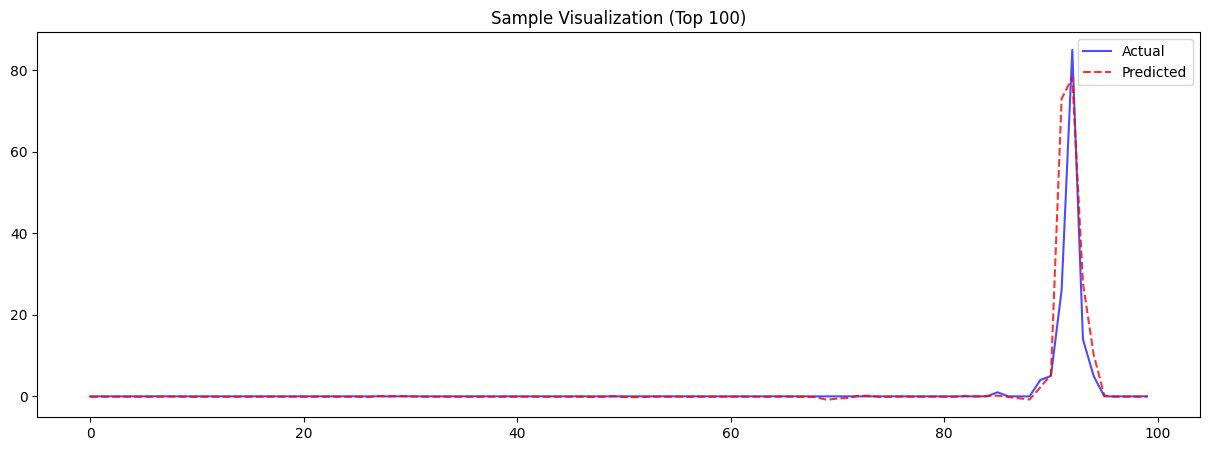

Saved 314400 samples to: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024/jun_dec_test_evaluation_results.npz


In [34]:

print("Evaluating held-out Jun-Dec 2024 test split...")
results = test_and_visualize(model1, test_loader, config, device, num_plot=100)

if results is not None and results[0] is not None:
    test_labels, test_preds = results
    save_path = os.path.join(DATA_ROOT, "jun_dec_test_evaluation_results.npz")
    np.savez_compressed(save_path, labels=test_labels, preds=test_preds)
    print(f"Saved {len(test_labels)} samples to: {save_path}")


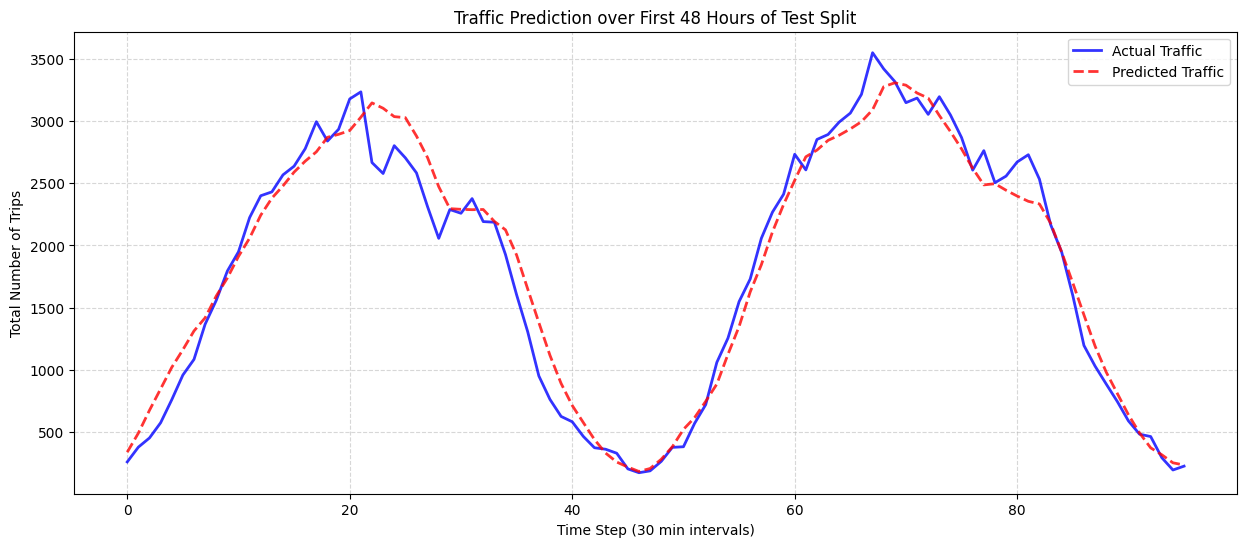

In [35]:

import numpy as np
import matplotlib.pyplot as plt

slots_48h = 96
cell_count = test_dataset.cell_count

n_time_total = test_labels.shape[0] // cell_count
test_labels_reshaped = test_labels[:, 0].reshape(n_time_total, cell_count)
test_preds_reshaped = test_preds[:, 0].reshape(n_time_total, cell_count)

actual_timeline = test_labels_reshaped[:slots_48h].sum(axis=1)
pred_timeline = test_preds_reshaped[:slots_48h].sum(axis=1)

plt.figure(figsize=(15, 6))
plt.plot(actual_timeline, label="Actual Traffic", color="blue", linewidth=2, alpha=0.8)
plt.plot(pred_timeline, label="Predicted Traffic", color="red", linestyle="--", linewidth=2, alpha=0.8)
plt.title("Traffic Prediction over First 48 Hours of Test Split")
plt.xlabel("Time Step (30 min intervals)")
plt.ylabel("Total Number of Trips")
plt.xticks(np.arange(0, slots_48h + 1, 20))
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()


In [36]:

import numpy as np
import os

save_path = os.path.join(DATA_ROOT, "jun_dec_test_evaluation_results.npz")

if "test_labels" in locals() and test_labels is not None:
    np.savez_compressed(save_path, labels=test_labels, preds=test_preds)
    print(f"Saved evaluation results to: {save_path}")
else:
    print("No test results found. Please run the evaluation cell first.")


Saved evaluation results to: /content/drive/MyDrive/mining_ofMassive/Data_V_F/prepare_6-12_2024/jun_dec_test_evaluation_results.npz
